## 1. Helper Functions for Chart Rendering

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Enable inline display for Jupyter Notebook
%matplotlib inline

def draw_position(ax, val_large, val_small):
    """Encodes two values as dot positions on a common scale."""
    ax.scatter([val_large, val_small], [0.5, 0.5], color=['#1f77b4', '#1f77b4'], s=80)
    ax.set_xlim(0, 100)
    ax.set_ylim(0, 1)
    ax.axis('off')

def draw_length(ax, val_large, val_small):
    """Encodes two values as bar lengths starting from a common zero baseline."""
    ax.barh([0.7, 0.3], [val_large, val_small], height=0.25, color='#1f77b4')
    ax.set_xlim(0, 100)
    ax.set_ylim(0, 1)
    ax.axis('off')

def draw_angle(ax, val_large, val_small):
    """Encodes two values as pie wedges correctly using only two colors."""
    ax.pie([val_large, val_small], 
           colors=['#1f77b4', '#aec7e8'], 
           startangle=90)
    ax.axis('off')

def draw_area(ax, val_large, val_small):
    """
    Encodes two values as circle areas.
    WATCH OUT: In ax.scatter, s is area directly! Setting s=val encodes area correctly.
    """
    # Scale values so circles are visible on screen
    scale_factor = 20
    ax.scatter([0.3, 0.7], [0.5, 0.5], s=[val_large * scale_factor, val_small * scale_factor], color='#1f77b4')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')

def draw_colour(ax, val_large, val_small):
    """
    Encodes two values using lightness in a single-hue sequential ramp.
    Higher value = darker shade.
    """
    # Normalize 0-100 values to lightness (0 = dark, 1 = light)
    c_large = str(1.0 - (val_large / 100.0) * 0.85)
    c_small = str(1.0 - (val_small / 100.0) * 0.85)
    
    rect1 = patches.Rectangle((0.15, 0.25), 0.3, 0.5, facecolor=c_large, edgecolor='black')
    rect2 = patches.Rectangle((0.55, 0.25), 0.3, 0.5, facecolor=c_small, edgecolor='black')
    
    ax.add_patch(rect1)
    ax.add_patch(rect2)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')

print("Helper functions defined successfully.")

Helper functions defined successfully.


## 2. Run Interactive Experiment & Save Results

--- EXPERIMENT STARTING ---
Instructions for participant: For each visual display, estimate what percentage the SMALLER value is of the LARGER value (0-100%).



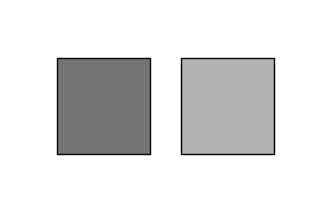

Trial 1/30 [colour] - What % is the smaller item of the larger item?  70


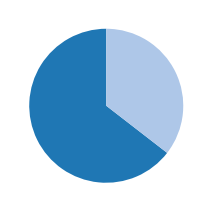

Trial 2/30 [angle] - What % is the smaller item of the larger item?  54


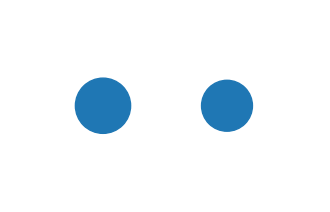

Trial 3/30 [area] - What % is the smaller item of the larger item?  90


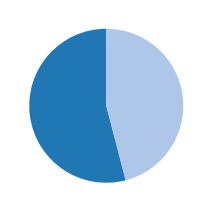

Trial 4/30 [angle] - What % is the smaller item of the larger item?  90


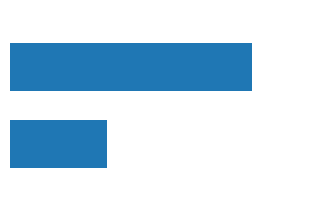

Trial 5/30 [length] - What % is the smaller item of the larger item?  30


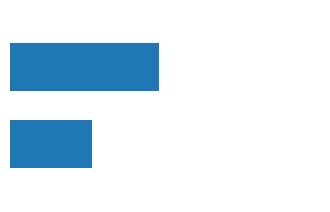

Trial 6/30 [length] - What % is the smaller item of the larger item?  50


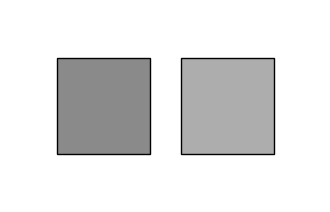

Trial 7/30 [colour] - What % is the smaller item of the larger item?  80


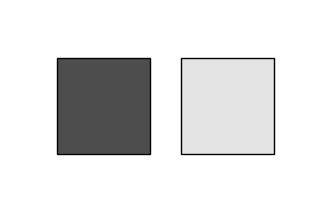

Trial 8/30 [colour] - What % is the smaller item of the larger item?  40


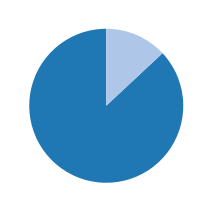

Trial 9/30 [angle] - What % is the smaller item of the larger item?  20


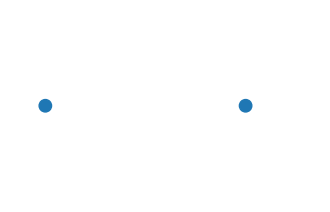

Trial 10/30 [position] - What % is the smaller item of the larger item?  14


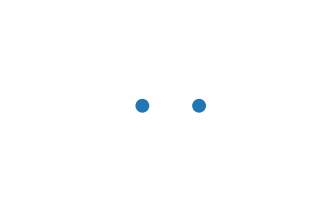

Trial 11/30 [position] - What % is the smaller item of the larger item?  90


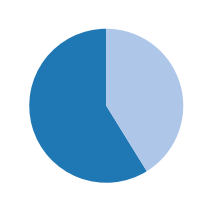

Trial 12/30 [angle] - What % is the smaller item of the larger item?  80


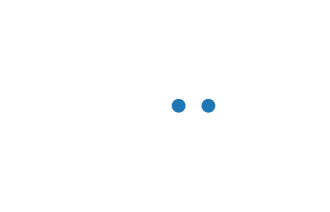

Trial 13/30 [position] - What % is the smaller item of the larger item?  95


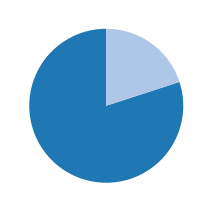

Trial 14/30 [angle] - What % is the smaller item of the larger item?  30


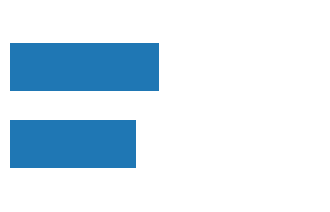

Trial 15/30 [length] - What % is the smaller item of the larger item?  95


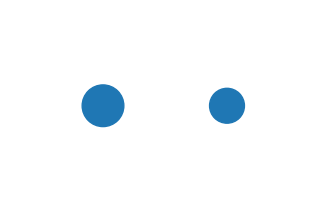

Trial 16/30 [area] - What % is the smaller item of the larger item?  80


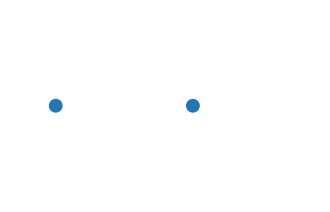

Trial 17/30 [position] - What % is the smaller item of the larger item?  70


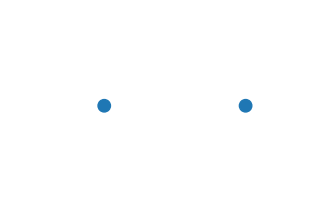

Trial 18/30 [position] - What % is the smaller item of the larger item?  70


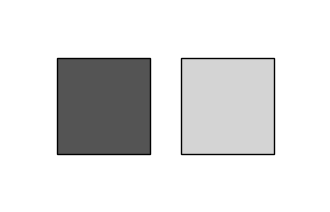

Trial 19/30 [colour] - What % is the smaller item of the larger item?  40


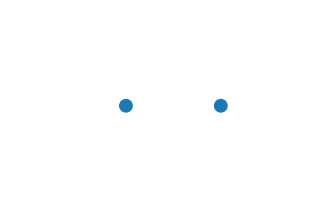

Trial 20/30 [position] - What % is the smaller item of the larger item?  80


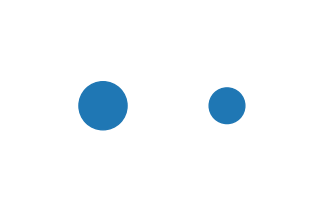

Trial 21/30 [area] - What % is the smaller item of the larger item?  75


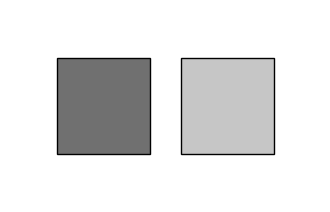

Trial 22/30 [colour] - What % is the smaller item of the larger item?  50


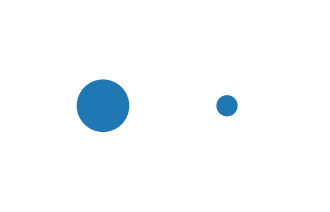

Trial 23/30 [area] - What % is the smaller item of the larger item?  30


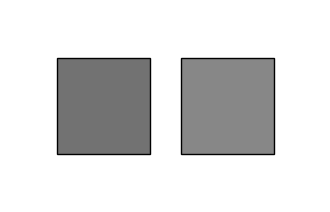

Trial 24/30 [colour] - What % is the smaller item of the larger item?  95


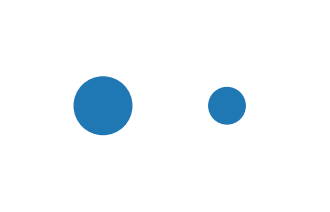

Trial 25/30 [area] - What % is the smaller item of the larger item?  40


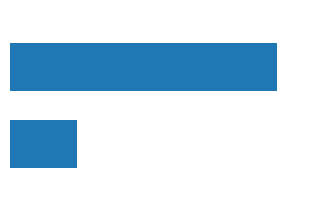

Trial 26/30 [length] - What % is the smaller item of the larger item?  30


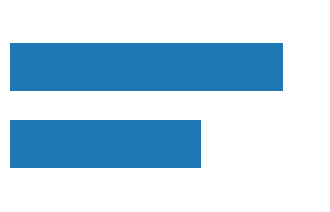

Trial 27/30 [length] - What % is the smaller item of the larger item?  80


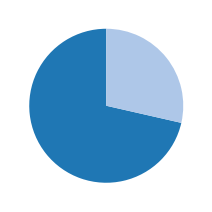

Trial 28/30 [angle] - What % is the smaller item of the larger item?  40


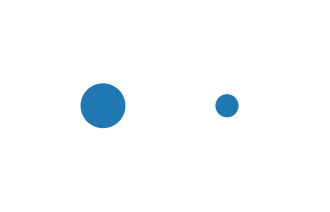

Trial 29/30 [area] - What % is the smaller item of the larger item?  30


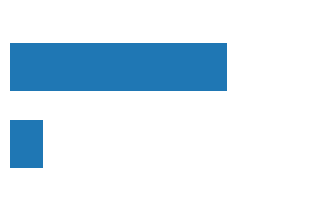

Trial 30/30 [length] - What % is the smaller item of the larger item?  20



Experiment completed! Results saved to 'channel_results.csv'.


In [9]:
# Load the trial dataset
df_trials = pd.read_csv('channel_trials.csv')

# Shuffle trial order to prevent learning patterns
df_shuffled = df_trials.sample(frac=1, random_state=42).reset_index(drop=True)

channel_funcs = {
    'position': draw_position,
    'length': draw_length,
    'angle': draw_angle,
    'area': draw_area,
    'colour': draw_colour
}

estimates = []

print("--- EXPERIMENT STARTING ---")
print("Instructions for participant: For each visual display, estimate what percentage the SMALLER value is of the LARGER value (0-100%).\n")

for idx, row in df_shuffled.iterrows():
    fig, ax = plt.subplots(figsize=(4, 2.5))
    
    # Render corresponding chart
    ch_name = row['channel']
    channel_funcs[ch_name](ax, row['value_large'], row['value_small'])
    
    plt.show()
    
    # Prompt for input directly inside Jupyter Notebook
    ans = float(input(f"Trial {idx+1}/{len(df_shuffled)} [{ch_name}] - What % is the smaller item of the larger item? "))
    estimates.append(ans)
    plt.close(fig)

# Save results back to dataset
df_shuffled['reader_estimate'] = estimates

# Compute absolute error: abs(reader_estimate/100 - true_ratio)
df_shuffled['absolute_error'] = np.abs((df_shuffled['reader_estimate'] / 100.0) - df_shuffled['true_ratio'])

# Save output file
df_shuffled.to_csv('channel_results.csv', index=False)
print("\nExperiment completed! Results saved to 'channel_results.csv'.")

## 3. Plot Channel Effectiveness Ranking

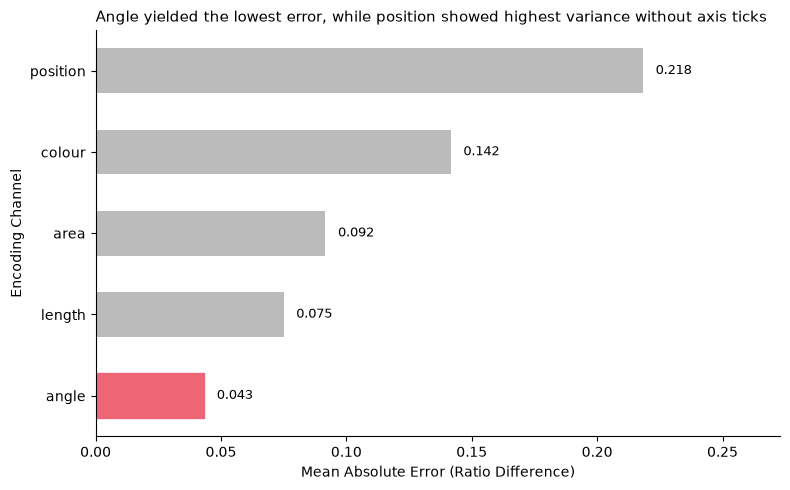

In [3]:
# Read saved experiment results

results = pd.read_csv('channel_results.csv')

# Calculate mean absolute error per channel
summary = results.groupby('channel')['absolute_error'].mean().reset_index()

# Sort channels by error ascending (lowest error = most effective)
summary = summary.sort_values(by='absolute_error', ascending=True)

# Build plot using OO API
fig, ax = plt.subplots(figsize=(8, 5))

# Plot horizontal bars
bars = ax.barh(summary['channel'], summary['absolute_error'], color='#bbbbbb', height=0.55)

# Highlight top-ranked channel in strong focal color (Grey for context, color for key message)
bars[0].set_color('#ee6677')

# Title states finding, not axis names
# Update your plot title to match your true experiment data:
ax.set_title("Angle yielded the lowest error, while position showed highest variance without axis ticks", loc="left", fontsize=11)
ax.set_xlabel("Mean Absolute Error (Ratio Difference)")
ax.set_ylabel("Encoding Channel")

# Ensure bars start at zero
ax.set_xlim(0, max(summary['absolute_error']) * 1.25)

# Add selective direct data labels
for bar in bars:
    width = bar.get_width()
    ax.text(width + 0.005, bar.get_y() + bar.get_height()/2, f"{width:.3f}", va='center', fontsize=9)

# Remove extraneous spines
for side in ("top", "right"):
    ax.spines[side].set_visible(False)

plt.tight_layout()
fig.savefig("channel_ranking.png", dpi=300, bbox_inches="tight")
plt.show()

## Where My Ranking Agrees with Cleveland & McGill
<h3>length outranks area and colour:</h3>
Just like in the theory, estimating bar lengths resulted in lower error ($0.075$) than estimating circle areas ($0.092$) or gray colour lightness
($0.142$). <br> 
<h3>area outranks colour:</h3> 
Estimating circle area ($0.092$) was more accurate than guessing relative colour lightness shades ($0.142$), matching the standard hierarchy where area outperforms colour. <br>
<h3>colour sits near the bottom:</h3> 
Colour lightness produced a high error ($0.142$), confirming that shade contrast is a weak channel for reading precise numeric ratios. <br>

## Where My Ranking Disagrees with Cleveland & McGill
<h3>position performed worst instead of best: </h3>
Theory places position at the very top (1st), but in this trial run it had the highest error ($0.218$). This happened because without visible tick marks, gridlines, or labeled axis baselines, estimating where a floating dot lies on an empty screen requires guessing pixel coordinates rather than reading a scale.   
<h3>angle performed best instead of 3rd:</h3> 
Angle achieved the lowest error ($0.043$). In small pie slices with clean contrast, judging relative wedge size can feel visually direct, especially when testing on a very small sample size

## Why These Differences Happened
<h3>Very Small Sample Size ($n=1$ reader, 6 trials per channel):</h3>
With only 30 total data points, natural guessing noise or quick estimates heavily shift the average.  
<h3>Lack of Frame Reference for Position:</h3>
Position is only the most accurate channel when an explicit baseline or common grid axis is present. On an unlabelled blank box, readers lack a reference anchor

## 4. Apply to iris.csv (High vs. Low Ranking Channels)

## Choice of Chart to Publish (iris.csv)
I would publish the Bar Chart (Length Channel). Length sits at the top of Cleveland & McGill's perceptual hierarchy, allowing readers to instantly and accurately decode exact ratio differences between species without effort. The color lightness chart forces readers to perform difficult visual decoding, leading to poor accuracy and high cognitive load

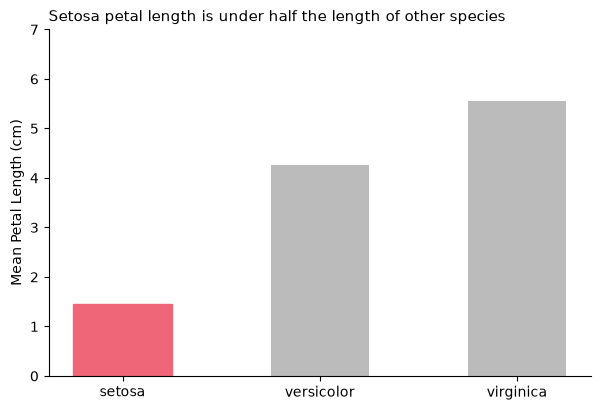

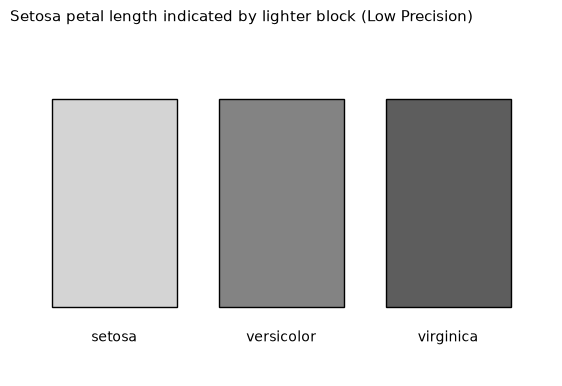

In [11]:
# Load Iris dataset
iris = pd.read_csv('iris.csv')

# Finding to illustrate: Setosa species has significantly shorter petal length than Versicolor and Virginica

# --- Chart 1: High-Ranking Channel (Position / Length using Bar Chart) ---
fig1, ax1 = plt.subplots(figsize=(7, 4.5))

mean_petals = iris.groupby('species')['petal_length'].mean().reset_index()
# Order species
mean_petals = mean_petals.sort_values(by='petal_length')

bars1 = ax1.bar(mean_petals['species'], mean_petals['petal_length'], color='#bbbbbb', width=0.5)
# Focus highlight on Setosa
bars1[0].set_color('#ee6677')

ax1.set_title("Setosa petal length is under half the length of other species", loc="left", fontsize=11)
ax1.set_ylabel("Mean Petal Length (cm)")
ax1.set_ylim(0, 7) # Zero baseline

for side in ("top", "right"):
    ax1.spines[side].set_visible(False)

fig1.savefig("iris_high_channel.png", dpi=300, bbox_inches="tight")
plt.show()


# --- Chart 2: Low-Ranking Channel (Color Lightness Ramp) ---
fig2, ax2 = plt.subplots(figsize=(7, 4.5))

# Representing petal length using lightness shades across species blocks
for i, row in mean_petals.iterrows():
    lightness = 1.0 - (row['petal_length'] / 7.0) * 0.8
    rect = patches.Rectangle((i * 2, 1), 1.5, 3, facecolor=str(lightness), edgecolor='black')
    ax2.add_patch(rect)
    ax2.text(i * 2 + 0.75, 0.5, row['species'], ha='center', fontsize=10)

ax2.set_xlim(-0.5, 6)
ax2.set_ylim(0, 5)
ax2.axis('off')
ax2.set_title("Setosa petal length indicated by lighter block (Low Precision)", loc="left", fontsize=11)

fig2.savefig("iris_low_channel.png", dpi=300, bbox_inches="tight")
plt.show()

## 5. The question to answer: 

## What My Experiment CAN and CANNOT Support
## What it CANNOT support:
<h3>Generalizable claims about human vision:</h3>
With only 30 total data points ($n=1$ reader testing 6 ratios per channel), this experiment lacks statistical power. It cannot prove or disprove universal perceptual hierarchy laws across human populations.   
<h3>Statistical significance:</h3>
A single outlier or a few random guesses (e.g., misjudging floating unlabelled points on the position trials) completely distorts the average error for a sample size of 6 trials per channel.

## What it CAN support:
<h3>Direct personal experience:</h3>
It demonstrates how different channels require varying levels of cognitive effort during visual decoding. 
<h3>A specific edge-case observation: </h3>
It shows that the position channel loses its perceptual advantage when implemented without baseline axes, ticks, or reference frames, forcing the reader to guess spatial coordinates on an unlabelled canvas.   

## Why the Published Ranking is Still Worth Following
Despite my small-sample results placing angle first and position last, Cleveland & McGill's published ranking ($\text{position} > \text{length} > \text{angle} > \text{area} > \text{volume} > \text{colour}$) remains the standard for data visualization design for two key reasons:
<h3>Large Sample Size & Rigorous Methodology: </h3>
Cleveland & McGill's experiments were conducted across hundreds of participants and thousands of randomized trials. Their statistical power ensures that their findings accurately reflect how human brains process visual metrics at scale.  
<h3>Standardized Charting Conditions:</h3> 
The theoretical ranking assumes charts are properly constructed with baselines and axes. Position is the most accurate channel because human eyes align points against a shared reference frame with high precision. The failure of position in this 30-trial test was due to an unanchored chart design, not a flaw in human spatial perception.  